In [13]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
import cv2
from skimage.feature import hog

RANDOM_SEED = 42
N_SAMPLES = 15000
IMG_SIZE = (64, 64)
TRAIN_LOW_TRAINSET_SIZE = True
TRAIN_AND_EVAL_SAME_DATASET = True
TRAIN_BIG_TRAINSET_SIZE = True

TARGET_COLS = ["race", "gender", "age"]

In [14]:
download_path = kagglehub.dataset_download("mehmoodsheikh/fairface-dataset")
print("Dataset cache útvonal:", download_path)

Using Colab cache for faster access to the 'fairface-dataset' dataset.
Dataset cache útvonal: /kaggle/input/fairface-dataset


In [15]:
DATASET_ROOT = download_path

TRAIN_DIR_PATH = os.path.join(DATASET_ROOT, "FairFace", "train")
VAL_DIR_PATH = os.path.join(DATASET_ROOT, "FairFace", "val")

TRAIN_CSV_PATH = os.path.join(DATASET_ROOT, "FairFace", "fairface_label_train.csv")
VAL_CSV_PATH = os.path.join(DATASET_ROOT, "FairFace", "fairface_label_val.csv")

print(TRAIN_DIR_PATH)
print(VAL_DIR_PATH)
print(TRAIN_CSV_PATH)
print(VAL_CSV_PATH)

/kaggle/input/fairface-dataset/FairFace/train
/kaggle/input/fairface-dataset/FairFace/val
/kaggle/input/fairface-dataset/FairFace/fairface_label_train.csv
/kaggle/input/fairface-dataset/FairFace/fairface_label_val.csv


In [16]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
val_df = pd.read_csv(VAL_CSV_PATH)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)

display(train_df.head())
print(train_df.columns)

full_df = pd.concat([train_df, val_df], ignore_index=True)
print("Full shape:", full_df.shape)

Train shape: (86744, 5)
Val shape: (10954, 5)


,file,age,gender,race,service_test
0,train/1.jpg,50-59,Male,East Asian,True
1,train/2.jpg,30-39,Female,Indian,False
2,train/3.jpg,3-9,Female,Black,False
3,train/4.jpg,20-29,Female,Indian,True
4,train/5.jpg,20-29,Female,Indian,True


Index(['file', 'age', 'gender', 'race', 'service_test'], dtype='object')
Full shape: (97698, 5)


In [17]:
df = train_df.sample(n=N_SAMPLES, random_state=RANDOM_SEED).reset_index(drop=True)

print("Sampled df shape:", df.shape)
for col in TARGET_COLS:
    print(f"\n{col} eloszlás:")
    print(df[col].value_counts())

Sampled df shape: (15000, 5)

race eloszlás:
race
White              2908
Latino_Hispanic    2338
Indian             2142
East Asian         2117
Black              2093
Southeast Asian    1775
Middle Eastern     1627
Name: count, dtype: int64

gender eloszlás:
gender
Male      7998
Female    7002
Name: count, dtype: int64

age eloszlás:
age
20-29           4468
30-39           3355
40-49           1813
3-9             1776
10-19           1534
50-59           1072
60-69            494
0-2              339
more than 70     149
Name: count, dtype: int64


In [18]:
FAIRFACE_ROOT = os.path.join(download_path, "FairFace")

X_list = []
meta_rows = []
valid_paths = []

In [19]:
def extract_raw_features(img_path, img_size=(64,64)):

    img = Image.open(img_path).convert("L")
    img = img.resize(img_size)

    arr = np.array(img, dtype=np.float32) / 255.0

    return arr.flatten()

def extract_equalized_features(img_path, img_size=(64,64)):

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, img_size)

    img_eq = cv2.equalizeHist(img)

    arr = img_eq.astype(np.float32) / 255.0

    return arr.flatten()

def extract_edge_features(img_path, img_size=(64,64)):

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, img_size)

    edges = cv2.Canny(img, 100, 200)

    arr = edges.astype(np.float32) / 255.0

    return arr.flatten()

def extract_hog_features(img_path, img_size=(64,64)):

    img = Image.open(img_path).convert("L")
    img = img.resize(img_size)

    img = np.array(img)

    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm="L2-Hys"
    )

    return features

def build_feature_matrix(df, extractor):

    X_list = []
    meta_rows = []

    for _, row in df.iterrows():

        img_file = row["file"]
        img_path = os.path.join(FAIRFACE_ROOT, img_file)

        features = extractor(img_path, img_size=IMG_SIZE)

        if features is not None:
            X_list.append(features)
            meta_rows.append(row)

    X = np.array(X_list)
    meta_df = pd.DataFrame(meta_rows).reset_index(drop=True)

    return X, meta_df

def train_and_evaluate_for_target(X, df_labels, target_col, min_class_ratio=None):
    print("\n" + "=" * 70)
    print(f"TARGET: {target_col.upper()}")
    print("=" * 70)

    # ----------------------------------------
    # Ritka osztályok szűrése százalék alapján
    # ----------------------------------------
    if min_class_ratio is not None:

        class_ratios = df_labels[target_col].value_counts(normalize=True)

        valid_classes = class_ratios[class_ratios >= min_class_ratio].index

        print("\nOsztályarányok:")
        print(class_ratios)

        print(f"\nSzűrés: min_class_ratio = {min_class_ratio}")
        print("Megtartott osztályok:", list(valid_classes))

        mask = df_labels[target_col].isin(valid_classes)

        X_filtered = X[mask]
        df_filtered = df_labels[mask].reset_index(drop=True)

    else:
        X_filtered = X
        df_filtered = df_labels.reset_index(drop=True)

    print("\nSzűrés utáni eloszlás:")
    print(df_filtered[target_col].value_counts())

    # ------------------------------------------------
    # 2. Label encoding
    # ------------------------------------------------
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df_filtered[target_col].values)

    print("\nOsztályok:", list(label_encoder.classes_))
    print("Kódolt címke példa:", y[:10])

    # ------------------------------------------------
    # 3. Train-test split
    # ------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered,
        y,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=y
    )

    print("Train:", X_train.shape, y_train.shape)
    print("Test:", X_test.shape, y_test.shape)

    # ------------------------------------------------
    # 4. Decision Tree
    # ------------------------------------------------
    dt_model = DecisionTreeClassifier(
        random_state=RANDOM_SEED,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5
    )

    dt_model.fit(X_train, y_train)
    y_pred_dt = dt_model.predict(X_test)

    dt_acc = accuracy_score(y_test, y_pred_dt)
    dt_f1 = f1_score(y_test, y_pred_dt, average="weighted")

    print(f"\nDecision Tree - {target_col}")
    print("Accuracy:", dt_acc)
    print("Weighted F1:", dt_f1)
    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))

    # cm_dt = confusion_matrix(y_test, y_pred_dt)

    # plt.figure(figsize=(10, 8))
    # sns.heatmap(
    #     cm_dt,
    #     annot=True,
    #     fmt="d",
    #     cmap="Blues",
    #     xticklabels=label_encoder.classes_,
    #     yticklabels=label_encoder.classes_
    # )
    # plt.title(f"Decision Tree - Confusion Matrix ({target_col})")
    # plt.xlabel("Predicted")
    # plt.ylabel("True")
    # plt.tight_layout()
    # plt.show()

    # plt.figure(figsize=(20, 10))
    # plot_tree(
    #     dt_model,
    #     filled=True,
    #     max_depth=3,
    #     fontsize=8,
    #     class_names=[str(c) for c in label_encoder.classes_]
    # )
    # plt.title(f"Decision Tree (első 3 szint) - {target_col}")
    # plt.show()

    # ------------------------------------------------
    # 5. Random Forest
    # ------------------------------------------------
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_SEED,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)

    rf_acc = accuracy_score(y_test, y_pred_rf)
    rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

    print(f"\nRandom Forest - {target_col}")
    print("Accuracy:", rf_acc)
    print("Weighted F1:", rf_f1)
    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

    # cm_rf = confusion_matrix(y_test, y_pred_rf)

    # plt.figure(figsize=(10, 8))
    # sns.heatmap(
    #     cm_rf,
    #     annot=True,
    #     fmt="d",
    #     cmap="Greens",
    #     xticklabels=label_encoder.classes_,
    #     yticklabels=label_encoder.classes_
    # )
    # plt.title(f"Random Forest - Confusion Matrix ({target_col})")
    # plt.xlabel("Predicted")
    # plt.ylabel("True")
    # plt.tight_layout()
    # plt.show()

    # importances = rf_model.feature_importances_
    # importance_map = importances.reshape(IMG_SIZE)

    # plt.figure(figsize=(6, 6))
    # plt.imshow(importance_map, cmap="hot")
    # plt.colorbar()
    # plt.title(f"Random Forest feature importance térkép - {target_col}")
    # plt.axis("off")
    # plt.show()

    return {
        "target": target_col,
        "label_encoder": label_encoder,
        "dt_model": dt_model,
        "rf_model": rf_model,
        "dt_accuracy": dt_acc,
        "dt_f1": dt_f1,
        "rf_accuracy": rf_acc,
        "rf_f1": rf_f1
    }

def train_and_evaluate_for_target_same(X, df_labels, target_col, min_class_ratio=None):
    print("\n" + "=" * 70)
    print(f"TARGET: {target_col.upper()} TRAIN AS EVAL")
    print("=" * 70)

    # ----------------------------------------
    # Ritka osztályok szűrése százalék alapján
    # ----------------------------------------
    if min_class_ratio is not None:

        class_ratios = df_labels[target_col].value_counts(normalize=True)

        valid_classes = class_ratios[class_ratios >= min_class_ratio].index

        print("\nOsztályarányok:")
        print(class_ratios)

        print(f"\nSzűrés: min_class_ratio = {min_class_ratio}")
        print("Megtartott osztályok:", list(valid_classes))

        mask = df_labels[target_col].isin(valid_classes)

        X_filtered = X[mask]
        df_filtered = df_labels[mask].reset_index(drop=True)

    else:
        X_filtered = X
        df_filtered = df_labels.reset_index(drop=True)

    print("\nSzűrés utáni eloszlás:")
    print(df_filtered[target_col].value_counts())

    # ------------------------------------------------
    # 2. Label encoding
    # ------------------------------------------------
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df_filtered[target_col].values)

    print("\nOsztályok:", list(label_encoder.classes_))
    print("Kódolt címke példa:", y[:10])

    # ------------------------------------------------
    # 3. Train-test split
    # ------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered,
        y,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=y
    )

    print("Train:", X_train.shape, y_train.shape)
    print("Test:", X_test.shape, y_test.shape)

    # ------------------------------------------------
    # 4. Decision Tree
    # ------------------------------------------------
    dt_model = DecisionTreeClassifier(
        random_state=RANDOM_SEED,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5
    )

    dt_model.fit(X_train, y_train)
    y_pred_dt = dt_model.predict(X_train)

    dt_acc = accuracy_score(y_train, y_pred_dt)
    dt_f1 = f1_score(y_train, y_pred_dt, average="weighted")

    print(f"\nDecision Tree - {target_col}")
    print("Accuracy:", dt_acc)
    print("Weighted F1:", dt_f1)
    print("\nClassification report:\n")
    print(classification_report(y_train, y_pred_dt, target_names=label_encoder.classes_))

    # cm_dt = confusion_matrix(y_test, y_pred_dt)

    # plt.figure(figsize=(10, 8))
    # sns.heatmap(
    #     cm_dt,
    #     annot=True,
    #     fmt="d",
    #     cmap="Blues",
    #     xticklabels=label_encoder.classes_,
    #     yticklabels=label_encoder.classes_
    # )
    # plt.title(f"Decision Tree - Confusion Matrix ({target_col})")
    # plt.xlabel("Predicted")
    # plt.ylabel("True")
    # plt.tight_layout()
    # plt.show()

    # plt.figure(figsize=(20, 10))
    # plot_tree(
    #     dt_model,
    #     filled=True,
    #     max_depth=3,
    #     fontsize=8,
    #     class_names=[str(c) for c in label_encoder.classes_]
    # )
    # plt.title(f"Decision Tree (első 3 szint) - {target_col}")
    # plt.show()

    # ------------------------------------------------
    # 5. Random Forest
    # ------------------------------------------------
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_SEED,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_train)

    rf_acc = accuracy_score(y_train, y_pred_rf)
    rf_f1 = f1_score(y_train, y_pred_rf, average="weighted")

    print(f"\nRandom Forest - {target_col}")
    print("Accuracy:", rf_acc)
    print("Weighted F1:", rf_f1)
    print("\nClassification report:\n")
    print(classification_report(y_train, y_pred_rf, target_names=label_encoder.classes_))

    # cm_rf = confusion_matrix(y_test, y_pred_rf)

    # plt.figure(figsize=(10, 8))
    # sns.heatmap(
    #     cm_rf,
    #     annot=True,
    #     fmt="d",
    #     cmap="Greens",
    #     xticklabels=label_encoder.classes_,
    #     yticklabels=label_encoder.classes_
    # )
    # plt.title(f"Random Forest - Confusion Matrix ({target_col})")
    # plt.xlabel("Predicted")
    # plt.ylabel("True")
    # plt.tight_layout()
    # plt.show()

    # importances = rf_model.feature_importances_
    # importance_map = importances.reshape(IMG_SIZE)

    # plt.figure(figsize=(6, 6))
    # plt.imshow(importance_map, cmap="hot")
    # plt.colorbar()
    # plt.title(f"Random Forest feature importance térkép - {target_col}")
    # plt.axis("off")
    # plt.show()

    return {
        "target": target_col,
        "label_encoder": label_encoder,
        "dt_model": dt_model,
        "rf_model": rf_model,
        "dt_accuracy": dt_acc,
        "dt_f1": dt_f1,
        "rf_accuracy": rf_acc,
        "rf_f1": rf_f1
    }

In [20]:
feature_extractors = {
    "raw_pixels": extract_raw_features,
    "equalized": extract_equalized_features,
    "edges": extract_edge_features,
    "hog": extract_hog_features
}


DATASET SIZE: 1000

############################################################
FEATURE TYPE: raw_pixels
############################################################

TARGET: RACE

Szűrés utáni eloszlás:
race
White              187
Latino_Hispanic    150
Black              150
East Asian         139
Southeast Asian    130
Indian             128
Middle Eastern     116
Name: count, dtype: int64

Osztályok: ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']
Kódolt címke példa: [4 4 2 0 2 3 1 3 4 6]
Train: (800, 4096) (800,)
Test: (200, 4096) (200,)

Decision Tree - race
Accuracy: 0.265
Weighted F1: 0.2516692798926842

Classification report:

                 precision    recall  f1-score   support

          Black       0.30      0.33      0.32        30
     East Asian       0.25      0.46      0.33        28
         Indian       0.10      0.08      0.09        26
Latino_Hispanic       0.09      0.07      0.08        30
 Middle Eastern  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TARGET: RACE

Szűrés utáni eloszlás:
race
White              187
Latino_Hispanic    150
Black              150
East Asian         139
Southeast Asian    130
Indian             128
Middle Eastern     116
Name: count, dtype: int64

Osztályok: ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']
Kódolt címke példa: [4 4 2 0 2 3 1 3 4 6]
Train: (800, 4096) (800,)
Test: (200, 4096) (200,)

Decision Tree - race
Accuracy: 0.22
Weighted F1: 0.21860727755331985

Classification report:

                 precision    recall  f1-score   support

          Black       0.26      0.37      0.30        30
     East Asian       0.35      0.29      0.31        28
         Indian       0.12      0.15      0.14        26
Latino_Hispanic       0.25      0.17      0.20        30
 Middle Eastern       0.20      0.17      0.19        23
Southeast Asian       0.18      0.23      0.20        26
          White       0.21      0.16      0.18        37

       accura

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Decision Tree - gender
Accuracy: 0.505
Weighted F1: 0.5054846727423363

Classification report:

              precision    recall  f1-score   support

      Female       0.46      0.48      0.47        92
        Male       0.54      0.53      0.54       108

    accuracy                           0.51       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.51      0.51      0.51       200


Random Forest - gender
Accuracy: 0.665
Weighted F1: 0.6610097594712979

Classification report:

              precision    recall  f1-score   support

      Female       0.66      0.55      0.60        92
        Male       0.67      0.76      0.71       108

    accuracy                           0.67       200
   macro avg       0.66      0.66      0.66       200
weighted avg       0.66      0.67      0.66       200


TARGET: AGE

Osztályarányok:
age
20-29           0.292
30-39           0.227
3-9             0.123
40-49           0.116
10-19           0.114
50-59   

...


TARGET: RACE

Szűrés utáni eloszlás:
race
White              585
Latino_Hispanic    473
Black              428
East Asian         408
Indian             394
Southeast Asian    369
Middle Eastern     343
Name: count, dtype: int64

Osztályok: ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']
Kódolt címke példa: [4 4 2 0 2 3 1 3 4 6]
Train: (2400, 1764) (2400,)
Test: (600, 1764) (600,)

Decision Tree - race
Accuracy: 0.17833333333333334
Weighted F1: 0.17250555196198203

Classification report:

                 precision    recall  f1-score   support

          Black       0.31      0.20      0.24        86
     East Asian       0.20      0.17      0.18        81
         Indian       0.16      0.14      0.15        79
Latino_Hispanic       0.17      0.14      0.15        94
 Middle Eastern       0.09      0.07      0.08        69
Southeast Asian       0.10      0.09      0.10        74
          White       0.19      0.34      0.25       1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,sample_size,feature,target,dt_accuracy,rf_accuracy,dt_f1,rf_f1
0,1000,raw_pixels,race,0.265000,0.280000,0.251669,0.238198
1,1000,raw_pixels,gender,0.535000,0.620000,0.535734,0.609147
2,1000,raw_pixels,age,0.191489,0.303191,0.188051,0.223717
3,1000,equalized,race,0.220000,0.295000,0.218607,0.249266
4,1000,equalized,gender,0.505000,0.665000,0.505485,0.661010
5,1000,equalized,age,0.207447,0.297872,0.204828,0.235860
6,1000,edges,race,0.165000,0.180000,0.141867,0.133124
7,1000,edges,gender,0.450000,0.555000,0.442775,0.521330
8,1000,edges,age,0.234043,0.297872,0.206571,0.189334
9,1000,hog,race,0.200000,0.280000,0.194222,0.252410


target                       age    gender      race
sample_size feature                                 
1000        edges       0.297872  0.555000  0.180000
            equalized   0.297872  0.665000  0.295000
            hog         0.303191  0.720000  0.280000
            raw_pixels  0.303191  0.620000  0.280000
3000        edges       0.322581  0.611667  0.220000
            equalized   0.362007  0.691667  0.263333
            hog         0.351254  0.716667  0.246667
            raw_pixels  0.311828  0.661667  0.285000

target                       age    gender      race
sample_size feature                                 
1000        edges       0.234043  0.450000  0.165000
            equalized   0.207447  0.505000  0.220000
            hog         0.260638  0.575000  0.200000
            raw_pixels  0.191489  0.535000  0.265000
3000        edges       0.283154  0.528333  0.158333
            equalized   0.275986  0.573333  0.213333
            hog         0.211470  0.600000  0.178333
            raw_pixels  0.250896  0.563333  0.236667

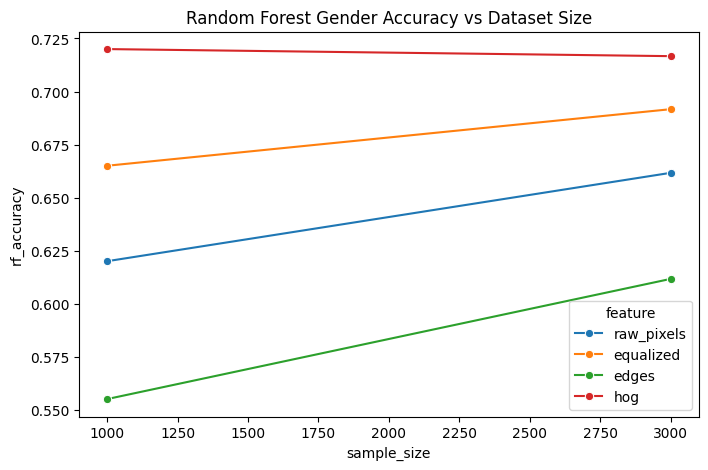

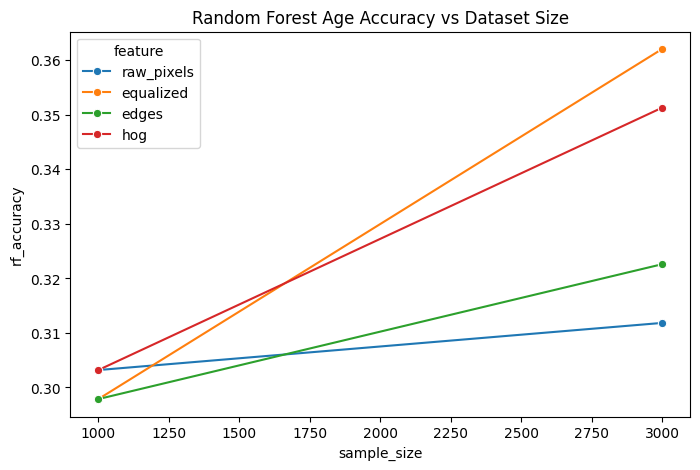

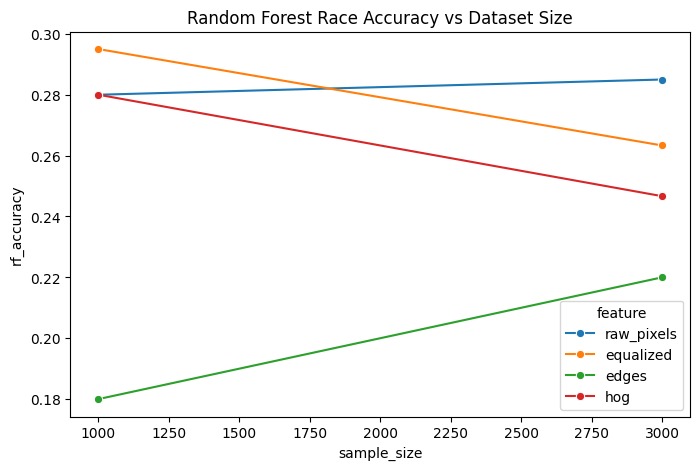

In [21]:
if TRAIN_LOW_TRAINSET_SIZE:
  sample_sizes = [1000, 3000]

  all_results = []

  for sample_size in sample_sizes:

      print("\n" + "="*80)
      print("DATASET SIZE:", sample_size)
      print("="*80)

      df_sample = train_df.sample(n=sample_size, random_state=RANDOM_SEED).reset_index(drop=True)

      for feature_name, extractor in feature_extractors.items():

          print("\n" + "#"*60)
          print("FEATURE TYPE:", feature_name)
          print("#"*60)

          X, meta_df = build_feature_matrix(df_sample, extractor)

          for target in ["race", "gender", "age"]:

              if target == "age":
                  res = train_and_evaluate_for_target(
                      X,
                      meta_df,
                      target,
                      min_class_ratio=0.05
                  )
              else:
                  res = train_and_evaluate_for_target(
                      X,
                      meta_df,
                      target
                  )

              all_results.append({
                  "sample_size": sample_size,
                  "feature": feature_name,
                  "target": target,
                  "dt_accuracy": res["dt_accuracy"],
                  "rf_accuracy": res["rf_accuracy"],
                  "dt_f1": res["dt_f1"],
                  "rf_f1": res["rf_f1"]
              })

  results_df = pd.DataFrame(all_results)
  display(results_df)

  pivot = results_df.pivot_table(
    index=["sample_size", "feature"],
    columns="target",
    values="rf_accuracy"
  )
  display(pivot)

  pivot = results_df.pivot_table(
    index=["sample_size", "feature"],
    columns="target",
    values="dt_accuracy"
  )

  display(pivot)

  plt.figure(figsize=(8,5))

  sns.lineplot(
      data=results_df[results_df["target"]=="gender"],
      x="sample_size",
      y="rf_accuracy",
      hue="feature",
      marker="o"
  )

  plt.title("Random Forest Gender Accuracy vs Dataset Size")
  plt.show()

  plt.figure(figsize=(8,5))

  sns.lineplot(
      data=results_df[results_df["target"]=="age"],
      x="sample_size",
      y="rf_accuracy",
      hue="feature",
      marker="o"
  )

  plt.title("Random Forest Age Accuracy vs Dataset Size")
  plt.show()

  plt.figure(figsize=(8,5))

  sns.lineplot(
      data=results_df[results_df["target"]=="race"],
      x="sample_size",
      y="rf_accuracy",
      hue="feature",
      marker="o"
  )

  plt.title("Random Forest Race Accuracy vs Dataset Size")
  plt.show()



DATASET SIZE: 1000

############################################################
FEATURE TYPE: raw_pixels
############################################################

TARGET: RACE TRAIN AS EVAL

Szűrés utáni eloszlás:
race
White              187
Latino_Hispanic    150
Black              150
East Asian         139
Southeast Asian    130
Indian             128
Middle Eastern     116
Name: count, dtype: int64

Osztályok: ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']
Kódolt címke példa: [4 4 2 0 2 3 1 3 4 6]
Train: (800, 4096) (800,)
Test: (200, 4096) (200,)

Decision Tree - race
Accuracy: 0.6825
Weighted F1: 0.6876635324552168

Classification report:

                 precision    recall  f1-score   support

          Black       0.80      0.70      0.75       120
     East Asian       0.45      0.80      0.57       111
         Indian       0.81      0.66      0.72       102
Latino_Hispanic       0.70      0.68      0.69       120
 M

,sample_size,feature,target,dt_accuracy,rf_accuracy,dt_f1,rf_f1
0,1000,raw_pixels,race,0.682500,0.992500,0.687664,0.992501
1,1000,raw_pixels,gender,0.931250,0.998750,0.931359,0.998750
2,1000,raw_pixels,age,0.698138,0.981383,0.703750,0.981300
3,1000,equalized,race,0.705000,1.000000,0.708854,1.000000
4,1000,equalized,gender,0.937500,0.997500,0.937512,0.997500
5,1000,equalized,age,0.750000,0.988032,0.744324,0.988029
6,1000,edges,race,0.520000,0.953750,0.524900,0.954813
7,1000,edges,gender,0.790000,0.957500,0.786691,0.957275
8,1000,edges,age,0.614362,0.740691,0.597922,0.717466
9,1000,hog,race,0.657500,1.000000,0.665688,1.000000


target                       age    gender      race
sample_size feature                                 
1000        edges       0.740691  0.957500  0.953750
            equalized   0.988032  0.997500  1.000000
            hog         0.996011  0.998750  1.000000
            raw_pixels  0.981383  0.998750  0.992500
3000        edges       0.650224  0.931250  0.908333
            equalized   0.969058  0.996250  0.998750
            hog         0.978027  0.999167  1.000000
            raw_pixels  0.933184  0.991667  0.987083

target                       age    gender      race
sample_size feature                                 
1000        edges       0.614362  0.790000  0.520000
            equalized   0.750000  0.937500  0.705000
            hog         0.768617  0.942500  0.657500
            raw_pixels  0.698138  0.931250  0.682500
3000        edges       0.480269  0.785417  0.450833
            equalized   0.651570  0.916250  0.632917
            hog         0.642152  0.900417  0.582500
            raw_pixels  0.566816  0.892500  0.569167

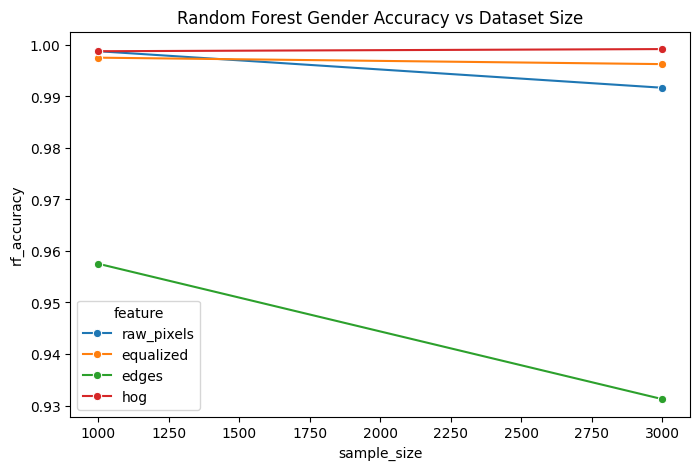

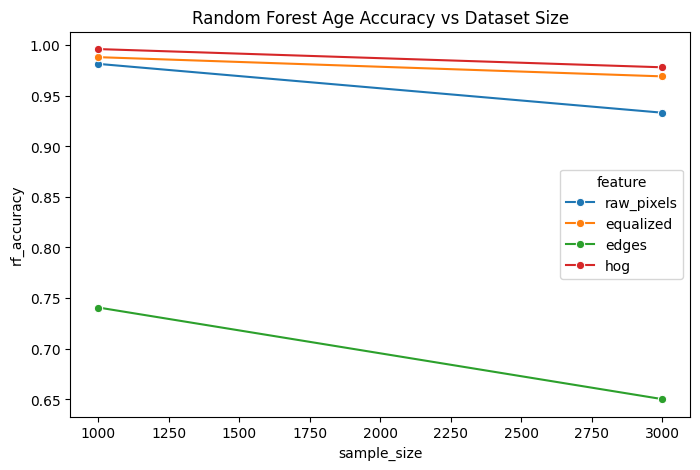

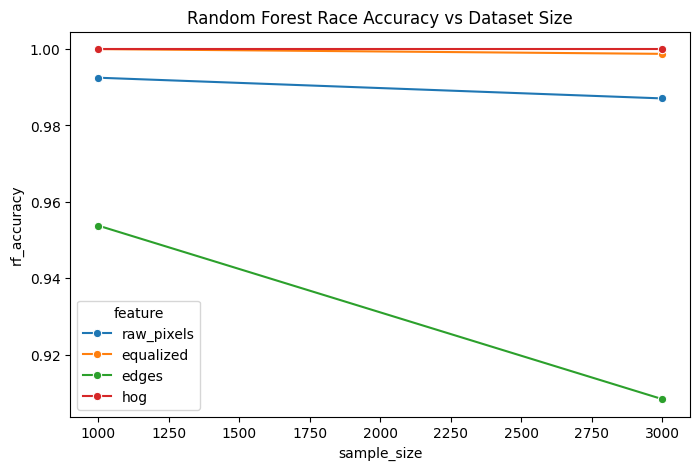

In [22]:
if TRAIN_AND_EVAL_SAME_DATASET:
  sample_sizes = [1000, 3000]

  all_results = []

  for sample_size in sample_sizes:

      print("\n" + "="*80)
      print("DATASET SIZE:", sample_size)
      print("="*80)

      df_sample = train_df.sample(n=sample_size, random_state=RANDOM_SEED).reset_index(drop=True)

      for feature_name, extractor in feature_extractors.items():

          print("\n" + "#"*60)
          print("FEATURE TYPE:", feature_name)
          print("#"*60)

          X, meta_df = build_feature_matrix(df_sample, extractor)

          for target in ["race", "gender", "age"]:

              if target == "age":
                  res = train_and_evaluate_for_target_same(
                      X,
                      meta_df,
                      target,
                      min_class_ratio=0.05
                  )
              else:
                  res = train_and_evaluate_for_target_same(
                      X,
                      meta_df,
                      target
                  )

              all_results.append({
                  "sample_size": sample_size,
                  "feature": feature_name,
                  "target": target,
                  "dt_accuracy": res["dt_accuracy"],
                  "rf_accuracy": res["rf_accuracy"],
                  "dt_f1": res["dt_f1"],
                  "rf_f1": res["rf_f1"]
              })

  results_df = pd.DataFrame(all_results)
  display(results_df)

  pivot = results_df.pivot_table(
    index=["sample_size", "feature"],
    columns="target",
    values="rf_accuracy"
  )
  display(pivot)

  pivot = results_df.pivot_table(
    index=["sample_size", "feature"],
    columns="target",
    values="dt_accuracy"
  )

  display(pivot)

  plt.figure(figsize=(8,5))

  sns.lineplot(
      data=results_df[results_df["target"]=="gender"],
      x="sample_size",
      y="rf_accuracy",
      hue="feature",
      marker="o"
  )

  plt.title("Random Forest Gender Accuracy vs Dataset Size")
  plt.show()

  plt.figure(figsize=(8,5))

  sns.lineplot(
      data=results_df[results_df["target"]=="age"],
      x="sample_size",
      y="rf_accuracy",
      hue="feature",
      marker="o"
  )

  plt.title("Random Forest Age Accuracy vs Dataset Size")
  plt.show()

  plt.figure(figsize=(8,5))

  sns.lineplot(
      data=results_df[results_df["target"]=="race"],
      x="sample_size",
      y="rf_accuracy",
      hue="feature",
      marker="o"
  )

  plt.title("Random Forest Race Accuracy vs Dataset Size")
  plt.show()


In [23]:
feature_extractors = {
    "hog": extract_hog_features
}


DATASET SIZE: 1000

############################################################
FEATURE TYPE: hog
############################################################

TARGET: RACE

Szűrés utáni eloszlás:
race
White              206
Indian             151
Latino_Hispanic    149
East Asian         148
Black              137
Southeast Asian    116
Middle Eastern      93
Name: count, dtype: int64

Osztályok: ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']
Kódolt címke példa: [0 6 0 0 2 6 4 6 5 1]
Train: (800, 1764) (800,)
Test: (200, 1764) (200,)

Decision Tree - race
Accuracy: 0.195
Weighted F1: 0.18414201059518395

Classification report:

                 precision    recall  f1-score   support

          Black       0.14      0.11      0.12        27
     East Asian       0.24      0.37      0.29        30
         Indian       0.18      0.13      0.15        30
Latino_Hispanic       0.13      0.13      0.13        30
 Middle Eastern       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Decision Tree - gender
Accuracy: 0.58
Weighted F1: 0.577001223990208

Classification report:

              precision    recall  f1-score   support

      Female       0.54      0.48      0.51        91
        Male       0.61      0.66      0.63       109

    accuracy                           0.58       200
   macro avg       0.57      0.57      0.57       200
weighted avg       0.58      0.58      0.58       200


Random Forest - gender
Accuracy: 0.705
Weighted F1: 0.6977402854980558

Classification report:

              precision    recall  f1-score   support

      Female       0.74      0.55      0.63        91
        Male       0.69      0.83      0.76       109

    accuracy                           0.70       200
   macro avg       0.71      0.69      0.69       200
weighted avg       0.71      0.70      0.70       200


TARGET: AGE

Osztályarányok:
age
20-29           0.294
30-39           0.222
3-9             0.116
40-49           0.108
10-19           0.102
50-59     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TARGET: RACE

Szűrés utáni eloszlás:
race
White              586
Indian             451
Latino_Hispanic    445
Black              437
East Asian         429
Southeast Asian    359
Middle Eastern     293
Name: count, dtype: int64

Osztályok: ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']
Kódolt címke példa: [0 6 0 0 2 6 4 6 5 1]
Train: (2400, 1764) (2400,)
Test: (600, 1764) (600,)

Decision Tree - race
Accuracy: 0.19166666666666668
Weighted F1: 0.1857460855201437

Classification report:

                 precision    recall  f1-score   support

          Black       0.20      0.30      0.24        87
     East Asian       0.25      0.17      0.20        86
         Indian       0.19      0.20      0.19        90
Latino_Hispanic       0.14      0.09      0.11        89
 Middle Eastern       0.12      0.10      0.11        59
Southeast Asian       0.17      0.14      0.15        72
          White       0.22      0.27      0.24       11

...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TARGET: RACE

Szűrés utáni eloszlás:
race
White              18612
Latino_Hispanic    14990
East Asian         13837
Indian             13835
Black              13789
Southeast Asian    12210
Middle Eastern     10425
Name: count, dtype: int64

Osztályok: ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']
Kódolt címke példa: [0 6 0 0 2 6 4 6 5 1]
Train: (78158, 1764) (78158,)
Test: (19540, 1764) (19540,)

Decision Tree - race
Accuracy: 0.24421699078812692
Weighted F1: 0.2309550381524277

Classification report:

                 precision    recall  f1-score   support

          Black       0.28      0.35      0.31      2758
     East Asian       0.33      0.30      0.31      2767
         Indian       0.22      0.24      0.23      2767
Latino_Hispanic       0.19      0.17      0.18      2998
 Middle Eastern       0.17      0.04      0.06      2085
Southeast Asian       0.20      0.13      0.15      2442
          White       0.24      0.3

,sample_size,feature,target,dt_accuracy,rf_accuracy,dt_f1,rf_f1
0,1000,hog,race,0.195000,0.310000,0.184142,0.267979
1,1000,hog,gender,0.580000,0.705000,0.577001,0.697740
2,1000,hog,age,0.218085,0.313830,0.221789,0.191103
3,3000,hog,race,0.191667,0.281667,0.185746,0.233492
4,3000,hog,gender,0.596667,0.688333,0.596793,0.679251
5,3000,hog,age,0.265125,0.330961,0.254516,0.213929
6,97698,hog,race,0.244217,0.328403,0.230955,0.275967
7,97698,hog,gender,0.642835,0.719345,0.638434,0.714792
8,97698,hog,age,0.313148,0.352864,0.274196,0.252707


,target,age,gender,race
sample_size,feature,,,
1000,hog,0.313830,0.705000,0.310000
3000,hog,0.330961,0.688333,0.281667
97698,hog,0.352864,0.719345,0.328403


,target,age,gender,race
sample_size,feature,,,
1000,hog,0.218085,0.580000,0.195000
3000,hog,0.265125,0.596667,0.191667
97698,hog,0.313148,0.642835,0.244217


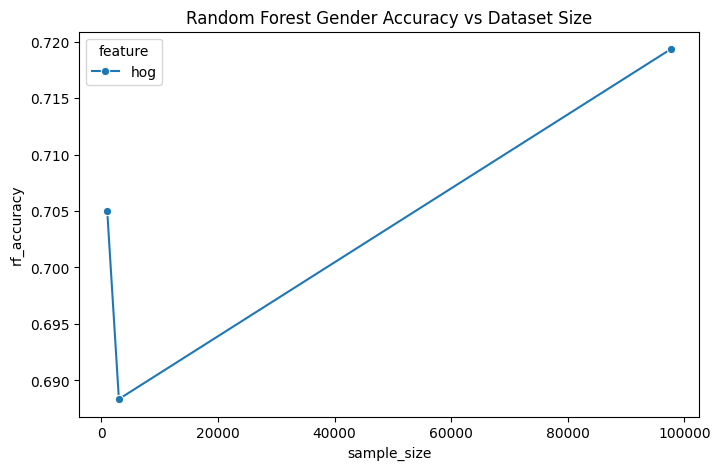

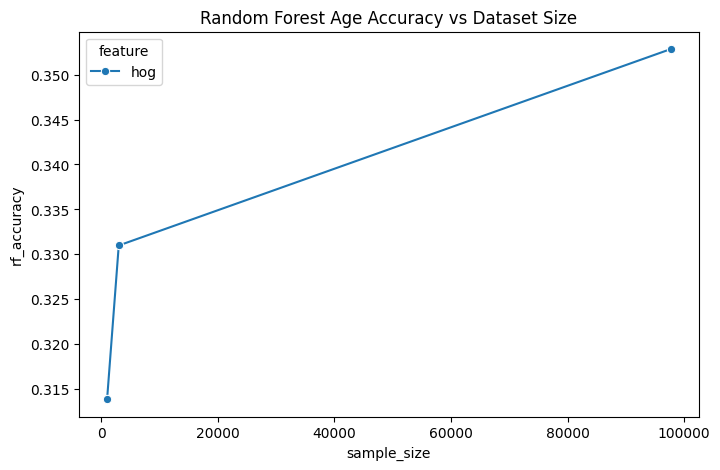

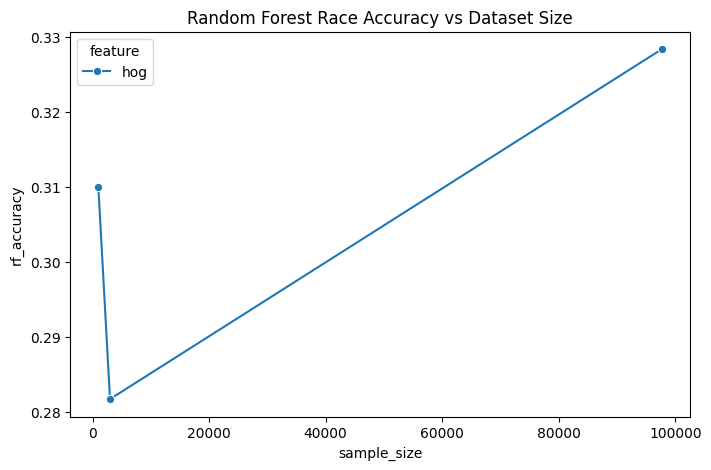

In [24]:
if TRAIN_BIG_TRAINSET_SIZE:
  sample_sizes = [1000, 3000, 97698]

  all_results = []

  for sample_size in sample_sizes:

      print("\n" + "="*80)
      print("DATASET SIZE:", sample_size)
      print("="*80)

      df_sample = full_df.sample(
            n=sample_size,
            random_state=RANDOM_SEED
        ).reset_index(drop=True)

      for feature_name, extractor in feature_extractors.items():

          print("\n" + "#"*60)
          print("FEATURE TYPE:", feature_name)
          print("#"*60)

          X, meta_df = build_feature_matrix(df_sample, extractor)

          for target in ["race", "gender", "age"]:

              if target == "age":
                  res = train_and_evaluate_for_target(
                      X,
                      meta_df,
                      target,
                      min_class_ratio=0.05
                  )
              else:
                  res = train_and_evaluate_for_target(
                      X,
                      meta_df,
                      target
                  )

              all_results.append({
                  "sample_size": sample_size,
                  "feature": feature_name,
                  "target": target,
                  "dt_accuracy": res["dt_accuracy"],
                  "rf_accuracy": res["rf_accuracy"],
                  "dt_f1": res["dt_f1"],
                  "rf_f1": res["rf_f1"]
              })

  results_df = pd.DataFrame(all_results)
  display(results_df)

  pivot = results_df.pivot_table(
    index=["sample_size", "feature"],
    columns="target",
    values="rf_accuracy"
  )
  display(pivot)

  pivot = results_df.pivot_table(
    index=["sample_size", "feature"],
    columns="target",
    values="dt_accuracy"
  )

  display(pivot)

  plt.figure(figsize=(8,5))

  sns.lineplot(
      data=results_df[results_df["target"]=="gender"],
      x="sample_size",
      y="rf_accuracy",
      hue="feature",
      marker="o"
  )

  plt.title("Random Forest Gender Accuracy vs Dataset Size")
  plt.show()

  plt.figure(figsize=(8,5))

  sns.lineplot(
      data=results_df[results_df["target"]=="age"],
      x="sample_size",
      y="rf_accuracy",
      hue="feature",
      marker="o"
  )

  plt.title("Random Forest Age Accuracy vs Dataset Size")
  plt.show()

  plt.figure(figsize=(8,5))

  sns.lineplot(
      data=results_df[results_df["target"]=="race"],
      x="sample_size",
      y="rf_accuracy",
      hue="feature",
      marker="o"
  )

  plt.title("Random Forest Race Accuracy vs Dataset Size")
  plt.show()
